<a href="https://colab.research.google.com/github/olgasherbiena/KPI/blob/main/%D0%90%D0%9A%D0%9C%D0%9C%D0%9D_lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Добро пожаловать в Colab!

In [1]:
!wget http://press.liacs.nl/mirflickr/mirflickr25k.v3b/mirflickr25k.zip

--2026-05-12 21:04:36--  http://press.liacs.nl/mirflickr/mirflickr25k.v3b/mirflickr25k.zip
Resolving press.liacs.nl (press.liacs.nl)... 132.229.137.37
Connecting to press.liacs.nl (press.liacs.nl)|132.229.137.37|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://press.liacs.nl/mirflickr/mirflickr25k.v3b/mirflickr25k.zip [following]
--2026-05-12 21:04:36--  https://press.liacs.nl/mirflickr/mirflickr25k.v3b/mirflickr25k.zip
Connecting to press.liacs.nl (press.liacs.nl)|132.229.137.37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3069184257 (2.9G) [application/zip]
Saving to: ‘mirflickr25k.zip’

mirflickr25k.zip    100%[===================>]   2.86G  75.0MB/s    in 53s     

2026-05-12 21:05:29 (55.7 MB/s) - ‘mirflickr25k.zip’ saved [3069184257/3069184257]



In [2]:
!unzip -q mirflickr25k.zip

In [3]:
import os, random, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from scipy.stats import gamma, vonmises

# --- Налаштування варіанту №12 (параметри №2) ---
base_path = "/content/mirflickr"
student_id = 12
random.seed(student_id)
sample_indices = random.sample(list(range(1, 20001)), 100) # 100 зображень

# Параметри завад (Варіант 12 -> Табл 1, №2)
# Випадкова: gamma(0.1, 1.0), vonmises(0, 1.0)
# Гармонійна: Амплітуда 2, Частота 24
H_AMP = 2
H_FREQ = 24

def add_noise(image):
    h, w = image.shape
    # 1. Гармонійна завада
    x = np.linspace(0, 1, w)
    y = np.linspace(0, 1, h)
    X, Y = np.meshgrid(x, y)
    harmonic = H_AMP * np.sin(2 * np.pi * H_FREQ * (X + Y))

    # 2. Випадкова завада (Суміш Gamma та Vonmises)
    noise_rnd = gamma.rvs(0.1, scale=1.0, size=(h, w)) + vonmises.rvs(1.0, loc=0, size=(h, w))

    noisy_img = image + harmonic + noise_rnd
    return np.clip(noisy_img, 0, 255).astype(np.uint8)

results_pca = []

# Обробка першого зображення для демонстрації
idx = sample_indices[0]
img = cv2.imread(os.path.join(base_path, f"im{idx}.jpg"), 0)
img_resized = cv2.resize(img, (640, 480), interpolation=cv2.INTER_LANCZOS4) # Lanczos

noisy = add_noise(img_resized)

# Реконструкція (від 5% до 95% компонент)
steps = np.arange(0.05, 1.0, 0.1)
for p in steps:
    n_comp = int(p * min(img_resized.shape))
    pca = PCA(n_components=n_comp)
    transformed = pca.fit_transform(noisy)
    reconstructed = pca.inverse_transform(transformed)

    # Метрики
    p_val = psnr(img_resized, reconstructed.astype(np.uint8))
    s_val = ssim(img_resized, reconstructed.astype(np.uint8))
    corr = np.corrcoef(img_resized.flatten(), reconstructed.flatten())[0, 1]

    results_pca.append({'Components_%': round(p*100), 'PSNR': p_val, 'SSIM': s_val, 'Pearson': corr})

print("📊 Результати очищення зображення (PCA):")
print(pd.DataFrame(results_pca))

📊 Результати очищення зображення (PCA):
   Components_%       PSNR      SSIM   Pearson
0             5  24.599217  0.740053  0.977478
1            15  29.364314  0.847909  0.992945
2            25  31.705134  0.901067  0.996765
3            35  33.749984  0.939038  0.998425
4            45  35.250640  0.962006  0.999161
5            55  37.308235  0.974652  0.999452
6            65  39.288339  0.978545  0.999515
7            75  40.947252  0.978369  0.999503
8            85  41.419365  0.977715  0.999494
9            95  41.333010  0.976963  0.999490


Середнє (Mean): Це математичне сподівання. Для пікселів (0–255) воно показує загальну яскравість каналу.

Дисперсія (Var): Другий центральний момент. Показує розкид кольорів (контрастність)

Асиметрія (Skew): Третій центральний момент. Від'ємна.
Від'ємна асиметрія означає, що лівий хвіст розподілу довший, а більша частина значень (маса) зосереджена праворуч, тобто у світлих тонах

Ексцес (Kurtosis): Четвертий центральний момент.
Це платикуртичний розподіл — він більш плоский, ніж нормальний, з менш вираженим піком

In [4]:
from sklearn.decomposition import FastICA

# --- Параметри сигналів (Варіант 12 -> Табл 2, №2) ---
T = 10 # 10 секунд
fs = 1000
t = np.linspace(0, T, T * fs)

# 1. Гармонійний (Амп: 6, Част: 33)
s1 = 6 * np.sin(2 * np.pi * 33 * t)
# 2. Трикутний (Амп: 9, Трив: 2)
s2 = 9 * (2 * np.abs(2 * (t/2 - np.floor(t/2 + 0.5))) - 1)
# 3. Цифровий (Прямокутний)
s3 = np.sign(np.sin(2 * np.pi * 2 * t))

S = np.c_[s1, s2, s3]

# Матриця змішування 3x3
A = np.array([[0.5, 0.2, 0.3], [0.1, 0.8, 0.1], [0.4, 0.4, 0.2]])
X = S.dot(A.T)

# Додаємо шум (згідно з варіантом №2 - Gamma/Vonmises)
noise = gamma.rvs(0.1, scale=1.0, size=X.shape)
X_noisy = X + 0.5 * noise

# FastICA
ica = FastICA(n_components=3)
S_reconstructed = ica.fit_transform(X_noisy)
A_reconstructed = ica.mixing_

print("\n✅ ICA розділення сигналів завершено.")
# Розрахунок метрик Pearson для сигналів
for i in range(3):
    corr = np.max([np.abs(np.corrcoef(S[:, i], S_reconstructed[:, j])[0,1]) for j in range(3)])
    print(f"Кореляція для сигналу {i+1}: {corr:.4f}")


✅ ICA розділення сигналів завершено.
Кореляція для сигналу 1: 0.9898
Кореляція для сигналу 2: 0.9990
Кореляція для сигналу 3: 0.2421


In [5]:
# --- Параметри (Варіант 12 -> Табл 3, №2) ---
L_mix = 26
N_img = 25
K_repeat = 4

# Спрощений приклад для 1 ітерації
def mix_images(indices, n_images, l_mixes):
    images = []
    for idx in indices[:n_images]:
        img = cv2.imread(os.path.join(base_path, f"im{idx}.jpg"), 0)
        images.append(cv2.resize(img, (100, 100)).flatten()) # Зменшуємо для швидкості

    images = np.array(images)
    W = np.random.rand(l_mixes, n_images)
    mixed = W.dot(images)
    return images, mixed

orig, mixed = mix_images(sample_indices, N_img, L_mix)

ica_img = FastICA(n_components=N_img)
recovered_img = ica_img.fit_transform(mixed.T).T

print(f"\n🎨 Реконструкція зображень ICA (L={L_mix}, N={N_img}) виконана.")


🎨 Реконструкція зображень ICA (L=26, N=25) виконана.


In [6]:
import os, random, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FastICA
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from scipy.stats import gamma, vonmises, pearsonr

# --- Ініціалізація вибірки (Пункт 1) ---
base_path = "/content/mirflickr"
student_id = 12
random.seed(student_id)
sample_indices = random.sample(list(range(1, 20001)), 100)

# --- Частина №1: PCA та очищення зображень ---

def process_part_1():
    print("🎬 Початок Частини №1 (PCA)...")
    idx = sample_indices[0]
    img = cv2.imread(os.path.join(base_path, f"im{idx}.jpg"), 0)

    # i. Lanczos resampling до 640x480
    img_res = cv2.resize(img, (640, 480), interpolation=cv2.INTER_LANCZOS4)

    # 2-3. Генерування завад (Варіант 12 -> Параметри №2)
    h, w = img_res.shape
    # Гармонійна: Амп=2, Част=24
    xx, yy = np.meshgrid(np.linspace(0, 1, w), np.linspace(0, 1, h))
    harmonic = 2 * np.sin(2 * np.pi * 24 * (xx + yy))
    # Випадкова: gamma(0.1, 1) + vonmises(0, 1)
    noise_rnd = gamma.rvs(0.1, scale=1.0, size=(h, w)) + vonmises.rvs(1.0, loc=0, size=(h, w))

    noisy_img = np.clip(img_res + harmonic + noise_rnd, 0, 255).astype(np.uint8)

    # 4-6. Реконструкція PCA (від 5% до 95% з кроком 10%)
    results = []
    components_pct = np.arange(0.05, 1.0, 0.1)

    for p in components_pct:
        n_comp = int(p * min(h, w))
        pca = PCA(n_components=n_comp)
        reconstructed = pca.inverse_transform(pca.fit_transform(noisy_img))
        reconstructed = np.clip(reconstructed, 0, 255).astype(np.uint8)

        # Метрики
        p_val = psnr(img_res, reconstructed)
        s_val = ssim(img_res, reconstructed)
        corr, _ = pearsonr(img_res.flatten(), reconstructed.flatten())

        results.append({'%': round(p*100), 'PSNR': p_val, 'SSIM': s_val, 'Pearson': corr})

    return pd.DataFrame(results), img_res, noisy_img

# --- Частина №2: FastICA (Сигнали) ---

def process_part_2():
    print("\n🎬 Початок Частини №2 (ICA Сигнали)...")
    fs = 1000
    t = np.linspace(0, 10, 10 * fs) # 10 секунд

    # 7.i. Сигнали (Варіант 12 -> №2)
    s1 = 6 * np.sin(2 * np.pi * 33 * t) # Гармонійний
    s2 = 9 * (2 * np.abs(2 * (t/2 - np.floor(t/2 + 0.5))) - 1) # Трикутний
    s3 = np.sign(np.sin(2 * np.pi * 2 * t)) # Цифровий (приклад)
    S = np.c_[s1, s2, s3]

    # 7.ii-iii. Змішування (Матриця 3x3)
    W_orig = np.array([[0.5, 0.2, 0.3], [0.1, 0.8, 0.1], [0.4, 0.4, 0.2]])
    X = S.dot(W_orig.T)

    # 7.iv. Додавання перешкоди n(t) (Gamma №2)
    noise = gamma.rvs(0.1, scale=1.0, size=X.shape)
    X_noisy = X + 0.5 * noise

    # 8-9. FastICA
    ica = FastICA(n_components=3, random_state=student_id)
    S_rec = ica.fit_transform(X_noisy)

    print("Метрики ICA сигналів (Pearson Correlation):")
    for i in range(3):
        corrs = [abs(pearsonr(S[:, i], S_rec[:, j])[0]) for j in range(3)]
        print(f"Сигнал {i+1}: Max Correlation = {max(corrs):.4f}")

# --- Запуск ---
df_pca, original, noisy = process_part_1()
print(df_pca)
process_part_2()

🎬 Початок Частини №1 (PCA)...
    %       PSNR      SSIM   Pearson
0   5  25.949375  0.745924  0.977497
1  15  30.901183  0.852772  0.992935
2  25  34.193976  0.906250  0.996754
3  35  37.155604  0.943005  0.998414
4  45  39.627660  0.965175  0.999150
5  55  41.191079  0.976294  0.999440
6  65  41.612766  0.979315  0.999502
7  75  41.517956  0.978477  0.999489
8  85  41.423744  0.977666  0.999475
9  95  41.336699  0.976867  0.999463

🎬 Початок Частини №2 (ICA Сигнали)...
Метрики ICA сигналів (Pearson Correlation):
Сигнал 1: Max Correlation = 0.9901
Сигнал 2: Max Correlation = 0.9991
Сигнал 3: Max Correlation = 0.2506



🎬 Початок Частини №3 (ICA для зображень)...


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Ітерація 1/4: Середній PSNR = 13.94


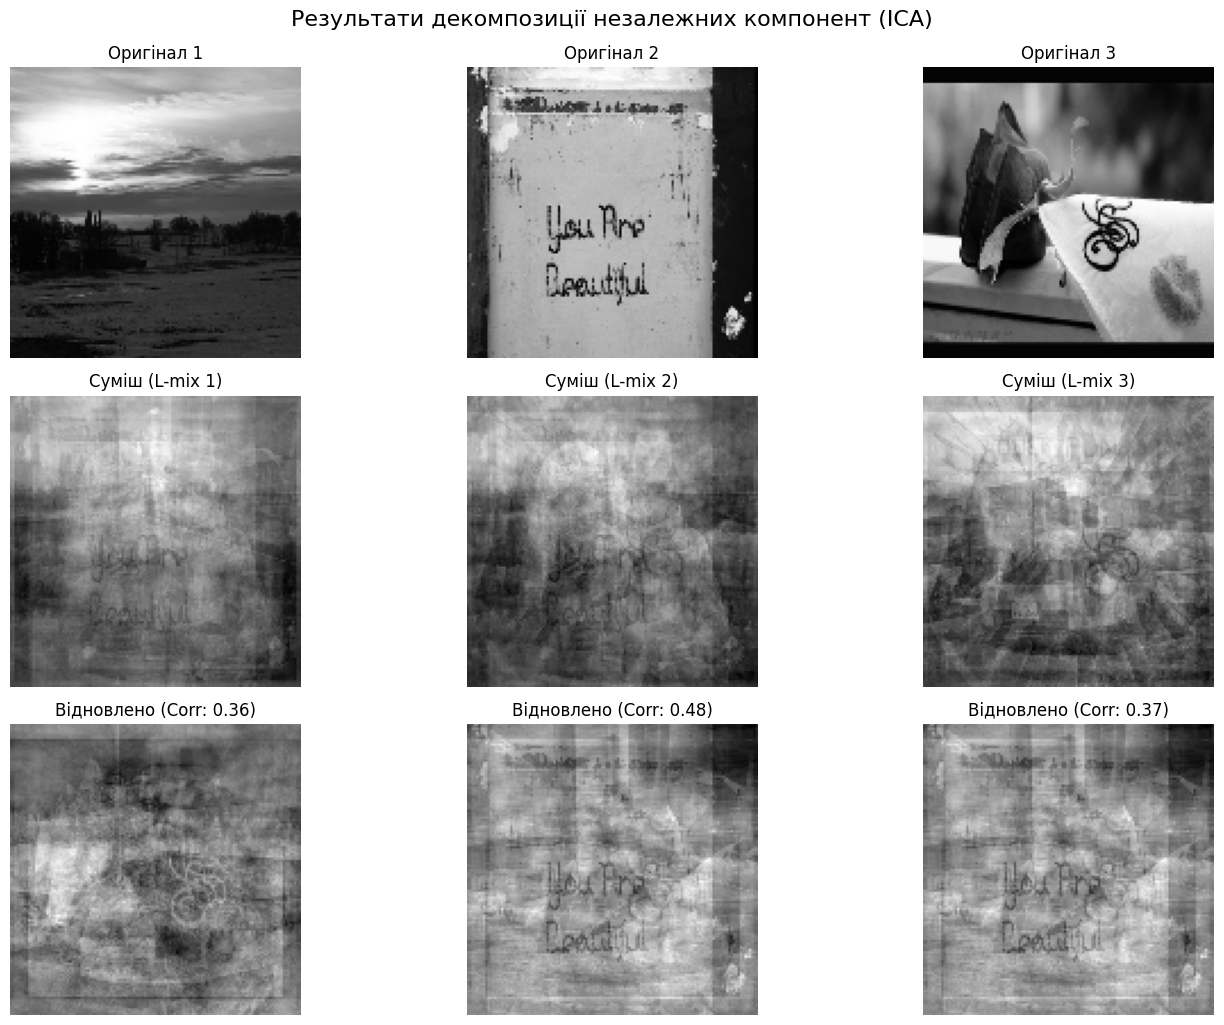

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Ітерація 2/4: Середній PSNR = 13.78


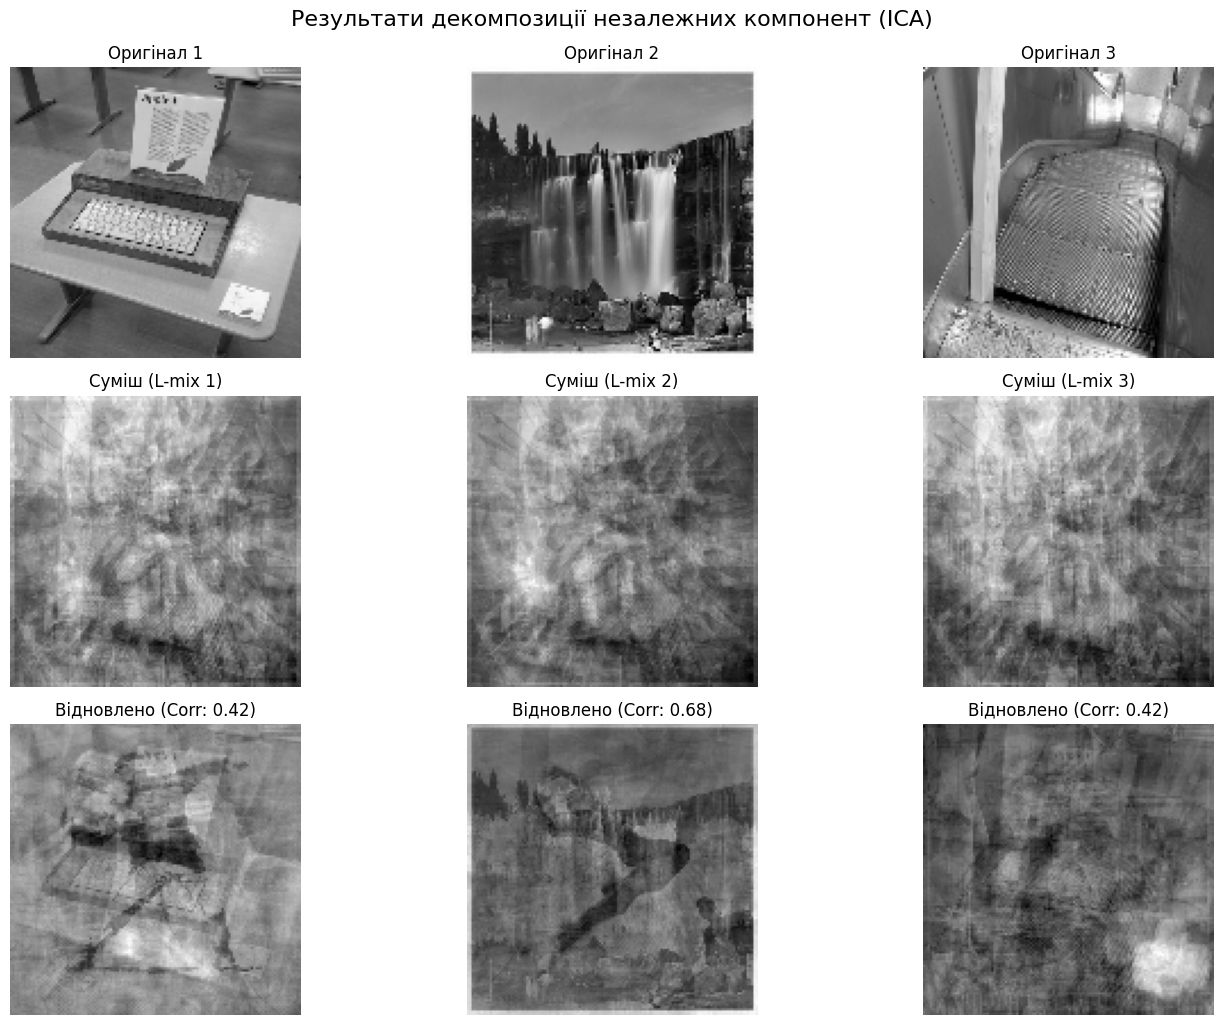

Ітерація 3/4: Середній PSNR = 13.43


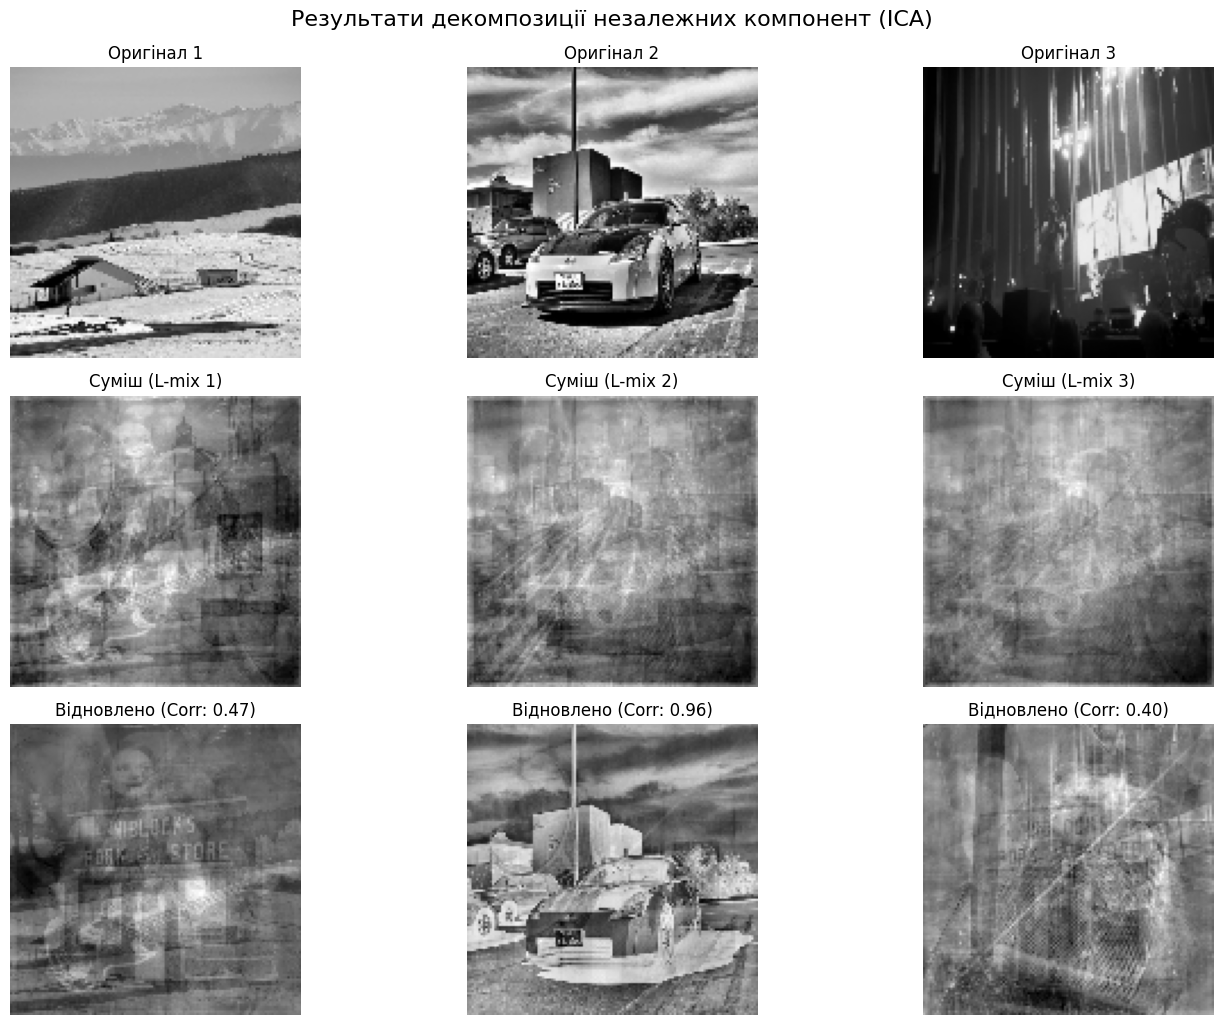

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Ітерація 4/4: Середній PSNR = 12.89


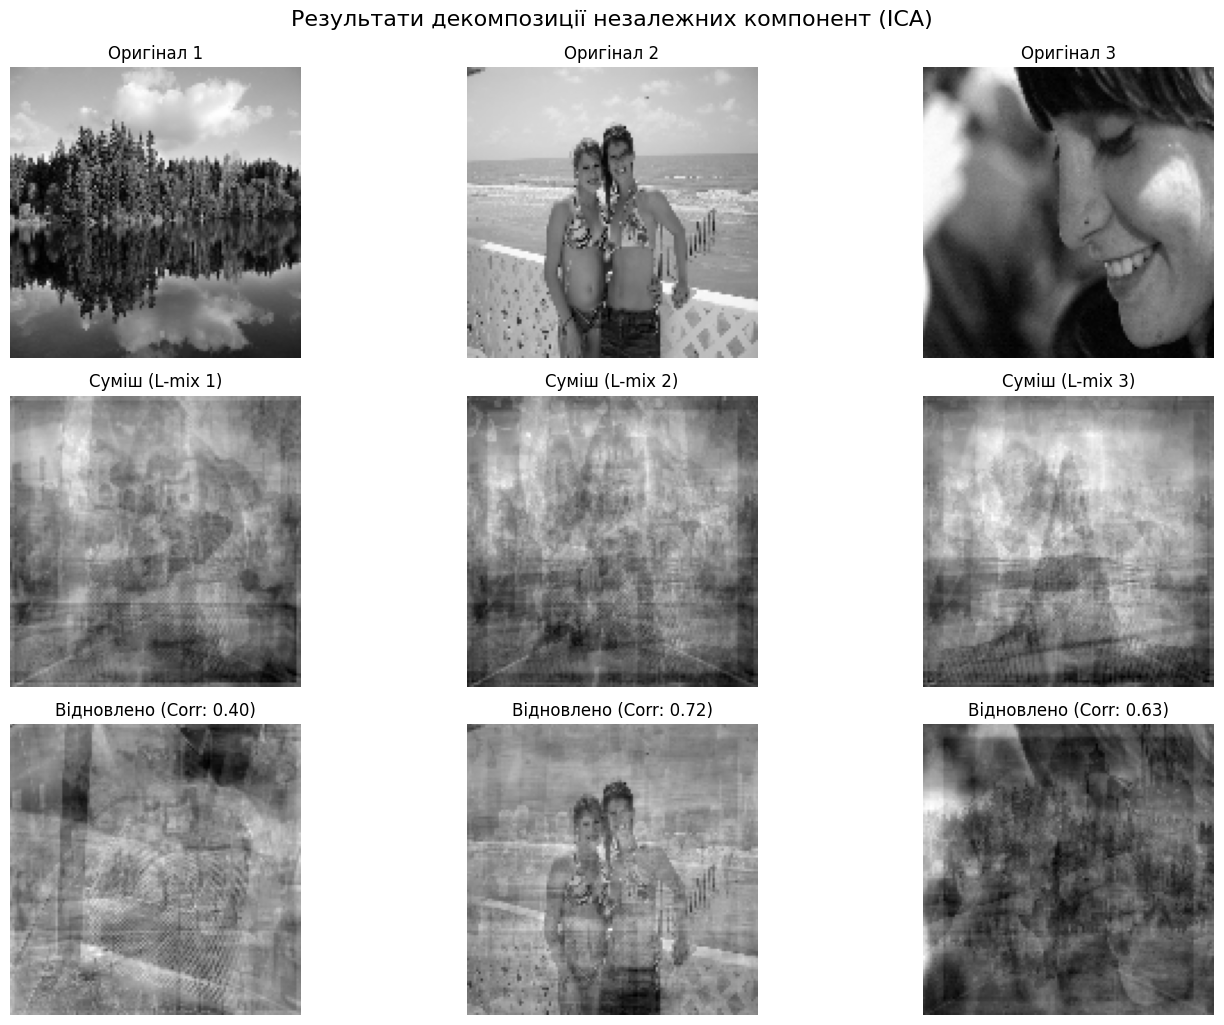


✅ ФІНАЛЬНІ РЕЗУЛЬТАТИ (усереднені за 4 разів):
Загальний середній PSNR: 13.51
Загальний середній SSIM: 0.3015


In [10]:
# --- Частина №3: ICA для двовимірних сигналів (Пункт 10-13) ---

def process_part_3():
    print("\n🎬 Початок Частини №3 (ICA для зображень)...")
    L_mix = 26
    N_img = 25
    K_repeat = 4

    avg_psnr = []
    avg_ssim = []

    for k in range(K_repeat):
        # 10. Вибираємо N псевдовипадкових зображень
        current_indices = random.sample(sample_indices, N_img)
        images = []
        for idx in current_indices:
            img = cv2.imread(os.path.join(base_path, f"im{idx}.jpg"), 0)
            img = cv2.resize(img, (128, 128)) # Зменшуємо для швидкості розрахунків
            images.append(img.flatten())

        S_img = np.array(images) # Вихідні сигнали

        # Генеруємо матрицю змішування L x N
        W = np.random.rand(L_mix, N_img)

        # Створюємо адитивні суміші
        X_img = W.dot(S_img)

        # 11. Реконструкція через FastICA
        ica_img = FastICA(n_components=N_img, random_state=student_id + k)
        S_rec_img = ica_img.fit_transform(X_img.T).T # Результат реконструкції

        # 12. Оцінка якості (PSNR, SSIM)
        iter_psnr = []
        iter_ssim = []

        for i in range(N_img):
            # ICA може міняти порядок сигналів, знаходимо найкращу відповідність
            best_p = 0
            best_s = 0
            for j in range(N_img):
                # Масштабуємо реконструйоване зображення до 0-255 для метрик
                rec_norm = cv2.normalize(S_rec_img[j].reshape(128, 128), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
                orig = S_img[i].reshape(128, 128).astype(np.uint8)

                curr_p = psnr(orig, rec_norm)
                if curr_p > best_p:
                    best_p = curr_p
                    best_s = ssim(orig, rec_norm)

            iter_psnr.append(best_p)
            iter_ssim.append(best_s)

        avg_psnr.append(np.mean(iter_psnr))
        avg_ssim.append(np.mean(iter_ssim))
        print(f"Ітерація {k+1}/{K_repeat}: Середній PSNR = {avg_psnr[-1]:.2f}")
        visualize_ica_results(S_img, X_img, S_rec_img)

    print(f"\n✅ ФІНАЛЬНІ РЕЗУЛЬТАТИ (усереднені за {K_repeat} разів):")
    print(f"Загальний середній PSNR: {np.mean(avg_psnr):.2f}")
    print(f"Загальний середній SSIM: {np.mean(avg_ssim):.4f}")

# Запуск фінальної частини
process_part_3()

In [8]:
def visualize_ica_results(orig_images, mixed_images, restored_images, n_to_show=3):
    plt.figure(figsize=(15, 10))

    for i in range(n_to_show):
        # 1. Оригінальне зображення
        plt.subplot(3, n_to_show, i + 1)
        plt.imshow(orig_images[i].reshape(128, 128), cmap='gray')
        plt.title(f"Оригінал {i+1}")
        plt.axis('off')

        # 2. Суміш (те, що бачить алгоритм спочатку)
        plt.subplot(3, n_to_show, i + 1 + n_to_show)
        plt.imshow(mixed_images[i].reshape(128, 128), cmap='gray')
        plt.title(f"Суміш (L-mix {i+1})")
        plt.axis('off')

        # 3. Відновлене зображення
        plt.subplot(3, n_to_show, i + 1 + 2*n_to_show)
        # Знаходимо найкращу відповідність для і-того оригіналу серед відновлених
        best_match_idx = 0
        max_corr = -1
        for j in range(len(restored_images)):
            corr = np.abs(np.corrcoef(orig_images[i], restored_images[j])[0,1])
            if corr > max_corr:
                max_corr = corr
                best_match_idx = j

        plt.imshow(restored_images[best_match_idx].reshape(128, 128), cmap='gray')
        plt.title(f"Відновлено (Corr: {max_corr:.2f})")
        plt.axis('off')

    plt.tight_layout()
    plt.suptitle("Результати декомпозиції незалежних компонент (ICA)", fontsize=16, y=1.02)
    plt.show()

# Виклич цю функцію після завершення FastICA у process_part_3:
# visualize_ica_results(S_img, X_img, S_rec_img)

In [9]:
# Перевіряємо, чи змінні існують перед викликом
if 'S_img' in locals() and 'X_img' in locals() and 'S_rec_img' in locals():
    print("🎨 Малюємо графіки ICA...")
    visualize_ica_results(S_img, X_img, S_rec_img)
else:
    print("❌ Помилка: Дані для візуалізації не знайдені. Спробуйте запустити попередні блоки.")

❌ Помилка: Дані для візуалізації не знайдені. Спробуйте запустити попередні блоки.
